<a href="https://colab.research.google.com/github/ashwinij-7/Machine-Learning/blob/main/KNN_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arunjangir245/boston-housing-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.6k/11.6k [00:00<00:00, 7.88MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/arunjangir245/boston-housing-dataset/versions/2


In [15]:
import os
os.listdir(path)

['BostonHousing.csv']

In [16]:
import pandas as pd
df = pd.read_csv(os.path.join(path, "BostonHousing.csv"))
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [17]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [27]:
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,5
age,0
dis,0
rad,0
tax,0


In [28]:
df['rm'] = df['rm'].fillna(df['rm'].mean())

In [56]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [57]:
X = df.drop("medv", axis=1)
y = df["medv"]

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
score_list = []

for k in range(1, 30):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    score_list.append(model.score(X_test, y_test))

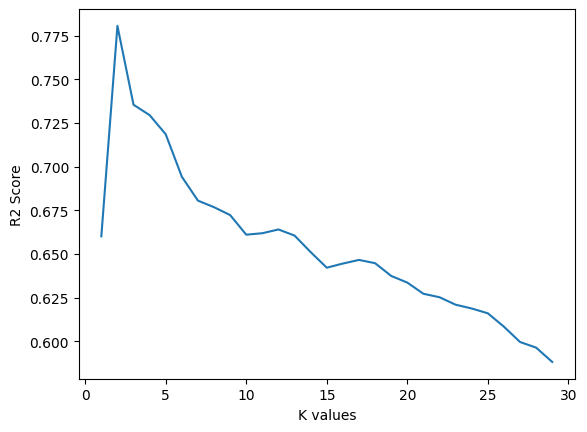

In [61]:
import matplotlib.pyplot as plt

plt.plot(range(1,30), score_list)

plt.xlabel("K values")
plt.ylabel("R2 Score")

plt.show()

In [62]:
final_model = KNeighborsRegressor(n_neighbors=3)

final_model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [63]:
y_pred = final_model.predict(X_test)

In [64]:
mean_squared_error(y_test, y_pred)

19.405424836601306

In [65]:
r2_score(y_test, y_pred)

0.7353821935767721